# Haenesl Data Quality Challenge
In this notebook, I address the coding challenge from Haensel as part of the recruitment from for a Data Scientist role.

## Simple reading guide
- **Q1** checks whether Adwords cost data is fully reflected in session tracking.
- **Q2** checks whether conversions look stable over the available dates.
- **Q3** reconciles the tracked conversions with the backend truth.
- **Q4** checks whether attribution weights and customer journeys make sense.
- **Q5** checks whether channel labels and channel volumes look stable.
- **Q6** highlights a few additional quality flags.


In [2]:
import os
import zipfile
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (10, 4.5)

In [4]:
db_path = "data/challenge.db"
conn = sqlite3.connect(db_path)

print("Using database:", db_path)

Using database: data/challenge.db


## 0) Basic overview

Let's see if all tables in the schema actually exist in the database drop.

In [5]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """
, conn)

tables

,name
0,api_adwords_costs
1,attribution_customer_journey
2,conversions
3,conversions_backend
4,session_sources


How large (how many rows) each table is?

In [6]:
for table_name in tables["name"]:
    rows = pd.read_sql_query(f"SELECT COUNT(*) AS rows FROM {table_name}", conn).iloc[0, 0]
    print(f"{table_name:30s} {rows:,}")


api_adwords_costs              2,987
attribution_customer_journey   22,499
conversions                    16,954
conversions_backend            17,283
session_sources                1,616,702


Are the tables' time ranges totally consistent?

In [7]:
date_ranges = []

for table_name, date_col in [
    ("session_sources", "event_date"),
    ("conversions", "conv_date"),
    ("conversions_backend", "conv_date"),
    ("api_adwords_costs", "event_date"),
]:
    rng = pd.read_sql_query(
        f"SELECT MIN({date_col}) AS min_date, MAX({date_col}) AS max_date FROM {table_name}",
        conn
    )
    date_ranges.append({
        "table": table_name,
        "date_column": date_col,
        "min_date": rng.loc[0, "min_date"],
        "max_date": rng.loc[0, "max_date"],
    })

pd.DataFrame(date_ranges)


,table,date_column,min_date,max_date
0,session_sources,event_date,2021-07-01,2021-07-31
1,conversions,conv_date,2021-07-15,2021-07-31
2,conversions_backend,conv_date,2021-07-15,2021-07-31
3,api_adwords_costs,event_date,2021-07-01,2021-07-31


Two tables beging from first of July whereas the other two begin mid July. So there is tiny incosistency between them. <br>
However, those needed to match still do.

# Q1) Are the costs in `api_adwords_costs` fully covered in `session_sources`?

### What this question means
For the same **date + campaign_id**, compare:

- what the ad platform says was spent (`api_adwords_costs`)
- what the session tracking table contains (`session_sources`)

If the two tables are aligned, then:
- API cost should be close to the sum of session CPC
- API clicks should be close to the number of session rows

### Why the join starts from the API table
The task asks whether API cost is **covered by** session data, so the API table is the reference set we preserve with a `LEFT JOIN`.


### Compute campaign cost and click-events' counts in both tables and comapre.

In [8]:
q1 = pd.read_sql_query(
    """
    WITH sess AS (
        SELECT
            event_date,
            campaign_id,
            COUNT(*) AS session_rows,
            SUM(cpc) AS session_cost
        FROM session_sources
        GROUP BY event_date, campaign_id
    ),
    api AS (
        SELECT
            event_date,
            campaign_id,
            SUM(cost) AS api_cost,
            SUM(clicks) AS api_clicks
        FROM api_adwords_costs
        GROUP BY event_date, campaign_id
    )
    SELECT
        a.event_date,
        a.campaign_id,
        a.api_cost,
        a.api_clicks,
        COALESCE(s.session_rows, 0) AS session_rows,
        COALESCE(s.session_cost, 0) AS session_cost,
        ROUND(a.api_cost - COALESCE(s.session_cost, 0), 6) AS cost_gap,
        a.api_clicks - COALESCE(s.session_rows, 0) AS click_gap

    FROM api a
    LEFT JOIN sess s
        ON a.event_date = s.event_date
       AND a.campaign_id = s.campaign_id
    ORDER BY a.event_date, a.campaign_id
    """
, conn)

print("Overview of the data:")
print(q1.head().to_string())


Overview of the data:
   event_date      campaign_id  api_cost  api_clicks  session_rows  session_cost  cost_gap  click_gap
0  2021-07-01   campaign_id_10    292.73         266           292       292.807    -0.077        -26
1  2021-07-01  campaign_id_100     11.57          17            17        11.572    -0.002          0
2  2021-07-01  campaign_id_101      8.90          15            16         8.899     0.001         -1
3  2021-07-01  campaign_id_103      6.01           7             7         5.460     0.550          0
4  2021-07-01  campaign_id_106     62.66          49            46        62.672    -0.012          3


### Aggregated results:

In [9]:
api_cost_total = q1["api_cost"].sum()
session_cost_total = q1["session_cost"].sum()
api_clicks_total = q1["api_clicks"].sum()
session_rows_total = q1["session_rows"].sum()

print(f"Total API cost:      {api_cost_total:,.2f}")
print(f"Total session cost:  {session_cost_total:,.2f}")
print(f"Cost gap:            {api_cost_total - session_cost_total:,.2f}")
print(f"Cost coverage %:     {session_cost_total / api_cost_total * 100:.2f}%")
print(f"Click coverage %:    {session_rows_total / api_clicks_total * 100:.2f}%")


Total API cost:      455,399.80
Total session cost:  442,453.33
Cost gap:            12,946.48
Cost coverage %:     97.16%
Click coverage %:    93.18%


**Cost coverage = 97%**

It is not perfect, so there is still a **reconciliation gap**:

- Some **campaign-days are missing**
- Some **costs are under-recorded**
- Some **campaigns do not match cleanly**



**Click coverage ≈ 93%** suggests that about **7% of ad clicks** are not showing up as matched sessions.

That can happen because:

- Some clicks were **not tracked as sessions**
- Campaign IDs / dates do **not match perfectly**
- Session logging **missed some traffic**
- API and session systems **record events differently**

### How `session_cost` and `api_cost` change together over time?

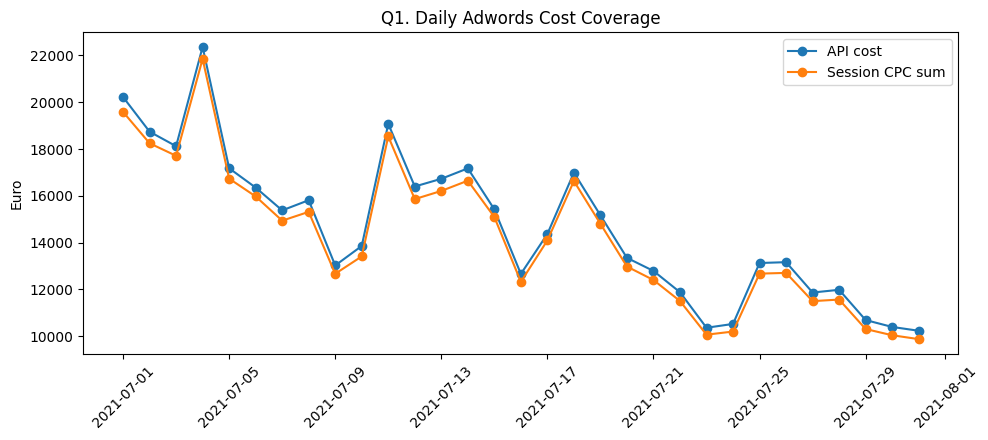

In [10]:
q1_daily = q1.groupby("event_date", as_index=False)[["api_cost", "session_cost", "api_clicks", "session_rows"]].sum()
q1_daily["event_date"] = pd.to_datetime(q1_daily["event_date"])


plt.figure(figsize=(10, 4.5))
plt.plot(q1_daily["event_date"], q1_daily["api_cost"], marker="o", label="API cost")
plt.plot(q1_daily["event_date"], q1_daily["session_cost"], marker="o", label="Session CPC sum")
plt.title("Q1. Daily Adwords Cost Coverage")
plt.ylabel("Euro")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The api cost and session cost are very close but api cost is always higher than session cost.

### The campaigns with largest cost gaps:

In [16]:
q1.groupby("campaign_id").sum().sort_values("cost_gap", ascending=False).head(15)["cost_gap"]

campaign_id
campaign_id_79     11756.158
campaign_id_97       254.480
campaign_id_121      174.830
campaign_id_73       153.737
campaign_id_94        81.009
campaign_id_52        80.553
campaign_id_35        75.733
campaign_id_156       53.191
campaign_id_5         48.887
campaign_id_7         30.274
campaign_id_3         23.182
campaign_id_22        21.720
campaign_id_147       20.676
campaign_id_96        19.811
campaign_id_64        15.160
Name: cost_gap, dtype: float64

         campaign_id   cost_gap  click_gap
94    campaign_id_79  11756.158       2342
107   campaign_id_97    254.480        272
13   campaign_id_121    174.830        246
89    campaign_id_73    153.737        855
104   campaign_id_94     81.009          6
69    campaign_id_52     80.553        835
57    campaign_id_35     75.733        482
37   campaign_id_156     53.191         18
66     campaign_id_5     48.887         41
86     campaign_id_7     30.274          1


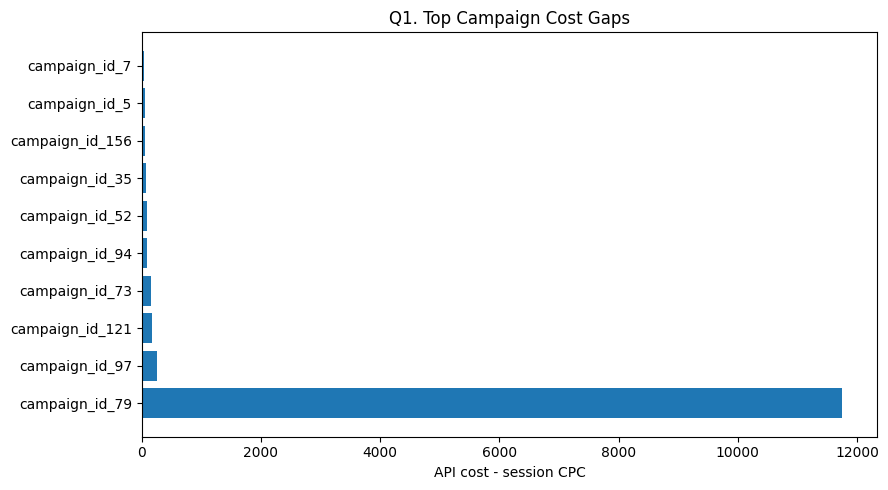

In [23]:
top_campaigns = q1.groupby("campaign_id")[["cost_gap", "click_gap"]].sum().reset_index().sort_values("cost_gap", ascending=False).head(10)
print(top_campaigns)
plt.figure(figsize=(9, 5))
plt.barh(top_campaigns["campaign_id"], top_campaigns["cost_gap"])
plt.title("Q1. Top Campaign Cost Gaps")
plt.xlabel("API cost - session CPC")
plt.tight_layout()
plt.show()

## Looking for issues

### Why `campaign_id_79` has such a large gap?

In [ ]:
q1[q1["campaign_id"] == "campaign_id_79"]["session_cost"].sum()

np.float64(0.0)

Since the session cost for this specific campaign is 0, there must be something wrong with this one. <br>
We can consider it as an outlier.

### Are there any campaigns in 'api_adwords_costs' table which don't show up in session_sources?

In [17]:
campaign_issues = pd.read_sql_query(
    """
    WITH sess AS (
        SELECT
            campaign_id,
            COUNT(*) AS session_rows,
            SUM(cpc) AS session_cost
        FROM session_sources
        GROUP BY campaign_id
    ),
    api AS (
        SELECT
            campaign_id,
            SUM(cost) AS api_cost,
            SUM(clicks) AS api_clicks
        FROM api_adwords_costs
        GROUP BY campaign_id
    )
    SELECT
        a.campaign_id,
        a.api_cost,
        a.api_clicks,
        COALESCE(s.session_rows, 0) AS session_rows,
        COALESCE(s.session_cost, 0) AS session_cost,
        ROUND(a.api_cost - COALESCE(s.session_cost, 0), 2) AS cost_gap,
        a.api_clicks - COALESCE(s.session_rows, 0) AS click_gap
    FROM api a
    LEFT JOIN sess s
        ON a.campaign_id = s.campaign_id
    ORDER BY ABS(a.api_cost - COALESCE(s.session_cost, 0)) DESC
    """
, conn)

campaign_issues.head(10)


,campaign_id,api_cost,api_clicks,session_rows,session_cost,cost_gap,click_gap
0,campaign_id_79,11756.158,23269,20927,0.000,11756.16,2342
1,campaign_id_97,254.480,272,0,0.000,254.48,272
2,campaign_id_121,174.830,246,0,0.000,174.83,246
3,campaign_id_73,5226.558,2094,1264,5072.821,153.74,830
4,campaign_id_94,121.749,27,21,40.740,81.01,6
5,campaign_id_52,12532.689,3441,2736,12452.136,80.55,705
6,campaign_id_35,7219.965,2472,1990,7144.232,75.73,482
7,campaign_id_156,144.014,48,30,90.823,53.19,18
8,campaign_id_5,760.599,292,251,711.712,48.89,41
9,campaign_id_7,368.986,135,135,338.712,30.27,0


In [24]:
missing_campaigns = campaign_issues[campaign_issues.session_rows == 0]["campaign_id"].values.tolist()
print(f"The following campaigns are missing in session_sources: {missing_campaigns}")

The following campaigns are missing in session_sources: ['campaign_id_97', 'campaign_id_121']


### Recompute the coverage after excluding the three suspicious campaigns: <br>
- The one outlier: `campaign_id_79`
- Two missing campaigns: `campaign_id_97`, `campaign_id_121`

In [24]:
suspicious_campaigns = ["campaign_id_79", "campaign_id_97", "campaign_id_121"]
q1_clean = q1[~q1["campaign_id"].isin(suspicious_campaigns)]

api_cost_total_clean = q1_clean["api_cost"].sum()
session_cost_total_clean = q1_clean["session_cost"].sum()
api_clicks_total_clean = q1_clean["api_clicks"].sum()
session_rows_total_clean = q1_clean["session_rows"].sum()

print(f"Total API cost:      {api_cost_total_clean:,.2f}")
print(f"Total session cost:  {session_cost_total_clean:,.2f}")
print(f"Cost gap:            {api_cost_total_clean - session_cost_total_clean:,.2f}")
print(f"Cost coverage %:     {session_cost_total_clean / api_cost_total_clean * 100:.2f}%")
print(f"Click coverage %:    {session_rows_total_clean / api_clicks_total_clean * 100:.2f}%")

Total API cost:      443,214.34
Total session cost:  442,453.33
Cost gap:            761.01
Cost coverage %:     99.83%
Click coverage %:    93.41%


### Let's re-check the change visually

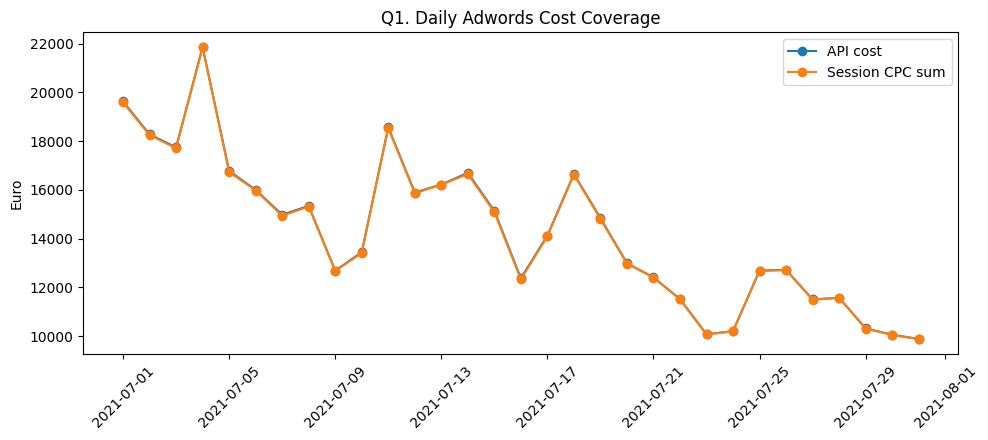

In [25]:
q1_daily_clean = q1_clean.groupby("event_date", as_index=False)[["api_cost", "session_cost", "api_clicks", "session_rows"]].sum()
q1_daily_clean["event_date"] = pd.to_datetime(q1_daily_clean["event_date"])


plt.figure(figsize=(10, 4.5))
plt.plot(q1_daily_clean["event_date"], q1_daily_clean["api_cost"], marker="o", label="API cost")
plt.plot(q1_daily_clean["event_date"], q1_daily_clean["session_cost"], marker="o", label="Session CPC sum")
plt.title("Q1. Daily Adwords Cost Coverage")
plt.ylabel("Euro")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Evidently, the three suspicious campaigns were responsible for most of the problems. <br>

**Simple conclusion for Q1**

- Overall coverage is high but not complete.
- The main problem campaign is **`campaign_id_79`**.
- **`campaign_id_97`** and **`campaign_id_121`** appear in API cost data but not in session data.
- A practical assumption in this comparison is that **session rows are the closest available counterpart to API clicks**.


# Q2) Are the conversions in `conversions` stable over time? Any pattern?

### What will be done:
I look at conversions by day and ask:

- do counts move smoothly or abruptly?
- do frontend and backend stay close?
- is there a visible spike or drop?

In [26]:
conv_daily = pd.read_sql_query(
    """
    SELECT
        conv_date,
        COUNT(*) AS conversions,
        SUM(revenue) AS total_revenue,
        AVG(revenue) AS avg_revenue
    FROM conversions
    GROUP BY conv_date
    ORDER BY conv_date
    """
, conn)

conv_daily


,conv_date,conversions,total_revenue,avg_revenue
0,2021-07-15,968,48140.04,49.731446
1,2021-07-16,809,38388.89,47.452274
2,2021-07-17,691,34721.01,50.247482
3,2021-07-18,1370,74555.65,54.420182
4,2021-07-19,842,41764.69,49.601770
5,2021-07-20,764,37678.05,49.316819
6,2021-07-21,783,37516.15,47.913346
7,2021-07-22,830,38041.52,45.833157
8,2021-07-23,743,36188.87,48.706420
9,2021-07-24,682,31101.09,45.602771


In [27]:
conv_compare_daily = pd.read_sql_query(
    """
    WITH c AS (
        SELECT conv_date, COUNT(*) AS cnt, SUM(revenue) AS rev
        FROM conversions
        GROUP BY conv_date
    ),
    b AS (
        SELECT conv_date, COUNT(*) AS cnt, SUM(revenue) AS rev
        FROM conversions_backend
        GROUP BY conv_date
    )
    SELECT
        b.conv_date,
        b.cnt AS backend_cnt,
        c.cnt AS front_cnt,
        b.rev AS backend_rev,
        c.rev AS front_rev,
        b.cnt - COALESCE(c.cnt, 0) AS cnt_gap,
        ROUND(b.rev - COALESCE(c.rev, 0), 2) AS rev_gap
    FROM b
    LEFT JOIN c
        ON b.conv_date = c.conv_date
    ORDER BY b.conv_date
    """
, conn)

conv_compare_daily


,conv_date,backend_cnt,front_cnt,backend_rev,front_rev,cnt_gap,rev_gap
0,2021-07-15,986,968,49637.75,48140.04,18,1497.71
1,2021-07-16,830,809,40003.75,38388.89,21,1614.86
2,2021-07-17,704,691,36164.40,34721.01,13,1443.39
3,2021-07-18,1401,1370,77011.74,74555.65,31,2456.09
4,2021-07-19,853,842,43024.79,41764.69,11,1260.10
5,2021-07-20,780,764,39020.80,37678.05,16,1342.75
6,2021-07-21,796,783,38329.93,37516.15,13,813.78
7,2021-07-22,851,830,39924.15,38041.52,21,1882.63
8,2021-07-23,759,743,37050.82,36188.87,16,861.95
9,2021-07-24,694,682,31886.57,31101.09,12,785.48


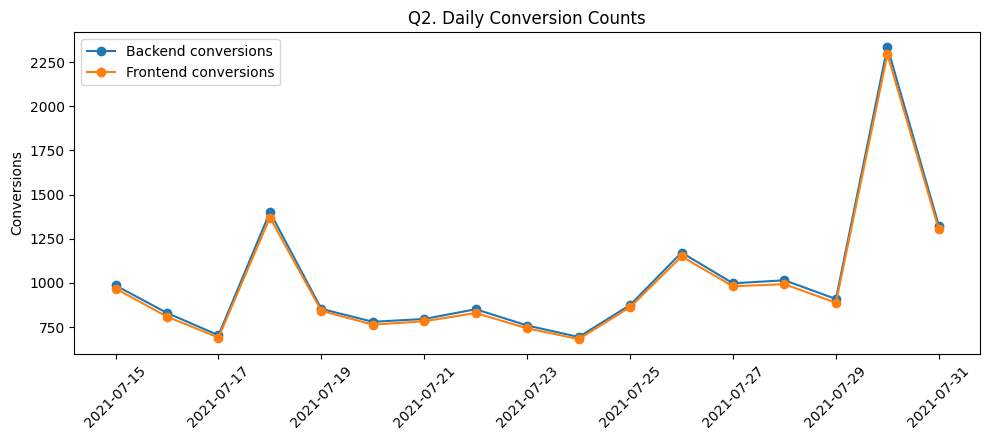

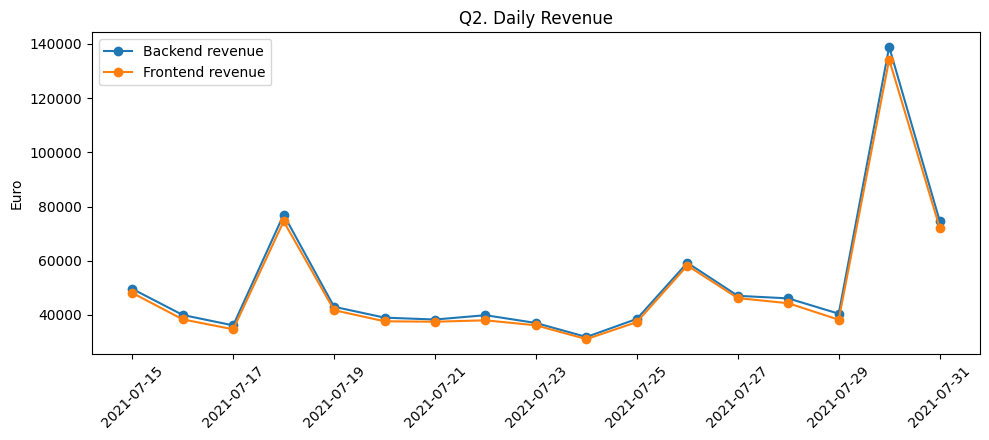

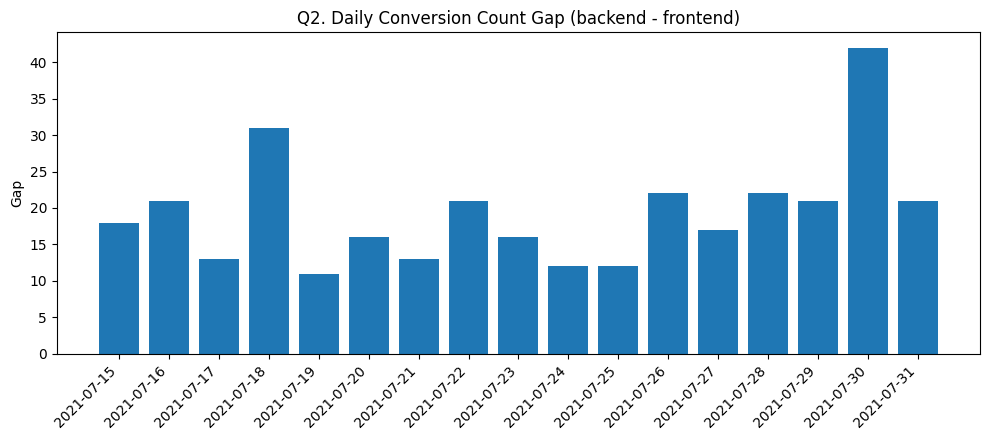

In [11]:
tmp = conv_compare_daily.copy()
tmp["conv_date"] = pd.to_datetime(tmp["conv_date"])

plt.figure(figsize=(10, 4.5))
plt.plot(tmp["conv_date"], tmp["backend_cnt"], marker="o", label="Backend conversions")
plt.plot(tmp["conv_date"], tmp["front_cnt"], marker="o", label="Frontend conversions")
plt.title("Q2. Daily Conversion Counts")
plt.ylabel("Conversions")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(tmp["conv_date"], tmp["backend_rev"], marker="o", label="Backend revenue")
plt.plot(tmp["conv_date"], tmp["front_rev"], marker="o", label="Frontend revenue")
plt.title("Q2. Daily Revenue")
plt.ylabel("Euro")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.bar(tmp["conv_date"].dt.strftime("%Y-%m-%d"), tmp["cnt_gap"])
plt.title("Q2. Daily Conversion Count Gap (backend - frontend)")
plt.ylabel("Gap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Simple conclusion for Q2**

- Over the available period, daily conversions look **fairly stable**.
- There is a clear spike on **2021-07-30**.
- The stronger data quality signal is that the frontend table is **below the backend table every day**.


# Q3) Double check `conversions` with `conversions_backend`

### What should be done
This is a direct reconciliation test. For each `conv_id`, ask:

- is it present in both tables?
- if yes, do `user_id`, `conv_date`, `market`, and `revenue` match?

According to the task states the `conversions_backend` is the **true** table.


### Is there any missing conversions?

In [31]:
missing_in_front = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n
    FROM conversions_backend b
    LEFT JOIN conversions c
        ON b.conv_id = c.conv_id
    WHERE c.conv_id IS NULL
    """
, conn)

missing_in_back = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n
    FROM conversions c
    LEFT JOIN conversions_backend b
        ON c.conv_id = b.conv_id
    WHERE b.conv_id IS NULL
    """
, conn)

print("Missing in conversions:", missing_in_front.iloc[0, 0])
print("Missing in backend:", missing_in_back.iloc[0, 0])


Missing in conversions: 345
Missing in backend: 0


### Count number of mismatch conversions

In [13]:
mismatch_summary = pd.read_sql_query(
    """
    SELECT
        SUM(CASE WHEN c.user_id != b.user_id THEN 1 ELSE 0 END) AS user_mismatch,
        SUM(CASE WHEN c.conv_date != b.conv_date THEN 1 ELSE 0 END) AS date_mismatch,
        SUM(CASE WHEN c.market != b.market THEN 1 ELSE 0 END) AS market_mismatch,
        SUM(CASE WHEN ABS(c.revenue - b.revenue) > 1e-9 THEN 1 ELSE 0 END) AS revenue_mismatch
    FROM conversions c
    JOIN conversions_backend b
        ON c.conv_id = b.conv_id
    """
, conn)

mismatch_summary


,user_mismatch,date_mismatch,market_mismatch,revenue_mismatch
0,16,0,0,172


In [36]:
bad_conversions = pd.read_sql_query(
    """
    SELECT
        c.conv_id,
        c.user_id AS c_user_id,
        b.user_id AS b_user_id,
        c.conv_date AS c_conv_date,
        b.conv_date AS b_conv_date,
        c.market AS c_market,
        b.market AS b_market,
        c.revenue AS c_revenue,
        b.revenue AS b_revenue

    FROM conversions c

    JOIN conversions_backend b ON c.conv_id = b.conv_id

    WHERE c_user_id != b_user_id
       OR c_conv_date != b_conv_date
       OR c_market != b_market
       OR ABS(c_revenue - b_revenue) > 1e-9

    ORDER BY c.conv_id
    """
, conn)

bad_conversions.head(20)


,conv_id,c_user_id,b_user_id,c_conv_date,b_conv_date,c_market,b_market,c_revenue,b_revenue
0,conv_id_10041,user_id_1147740,user_id_1147740,2021-07-30,2021-07-30,NL,NL,0.00,51.56
1,conv_id_10055,user_id_815190,user_id_815190,2021-07-28,2021-07-28,GB,GB,0.00,7.50
2,conv_id_10449,user_id_665055,user_id_665055,2021-07-21,2021-07-21,DE,DE,0.00,130.12
3,conv_id_10480,user_id_662105,user_id_662105,2021-07-30,2021-07-30,NL,NL,0.00,42.97
4,conv_id_10545,user_id_7939,user_id_7939,2021-07-30,2021-07-30,NL,NL,0.00,34.38
5,conv_id_1056,user_id_484328,user_id_484328,2021-07-15,2021-07-15,GB,GB,0.00,15.79
6,conv_id_10730,user_id_470610,user_id_470610,2021-07-30,2021-07-30,GB,GB,0.00,116.00
7,conv_id_10765,user_id_1394,user_id_1394,2021-07-27,2021-07-27,DE,DE,0.00,34.03
8,conv_id_10781,user_id_808017,user_id_808017,2021-07-22,2021-07-22,GB,GB,0.00,253.56
9,conv_id_10826,user_id_197806,user_id_172209,2021-07-30,2021-07-30,NL,NL,44.96,44.96


We can see that 

In [15]:
zero_revenue_bug = pd.read_sql_query(
    """
    SELECT COUNT(*) AS n
    FROM conversions c
    JOIN conversions_backend b
        ON c.conv_id = b.conv_id
    WHERE c.revenue = 0
      AND b.revenue > 0
    """
, conn)

print(f"Zero-revenue conversions in frontend that are positive in backend: {zero_revenue_bug.iloc[0, 0]}")


Zero-revenue conversions in frontend that are positive in backend: 172


In [16]:
issue_counts = pd.DataFrame({
    "Issue": [
        "Missing in frontend",
        "Missing in backend",
        "Revenue mismatch",
        "User mismatch",
        "Date mismatch",
        "Market mismatch",
    ],
    "Count": [
        int(missing_in_front.iloc[0, 0]),
        int(missing_in_back.iloc[0, 0]),
        int(mismatch_summary.loc[0, "revenue_mismatch"]),
        int(mismatch_summary.loc[0, "user_mismatch"]),
        int(mismatch_summary.loc[0, "date_mismatch"]),
        int(mismatch_summary.loc[0, "market_mismatch"]),
    ]
})
issue_counts


,Issue,Count
0,Missing in frontend,345
1,Missing in backend,0
2,Revenue mismatch,172
3,User mismatch,16
4,Date mismatch,0
5,Market mismatch,0


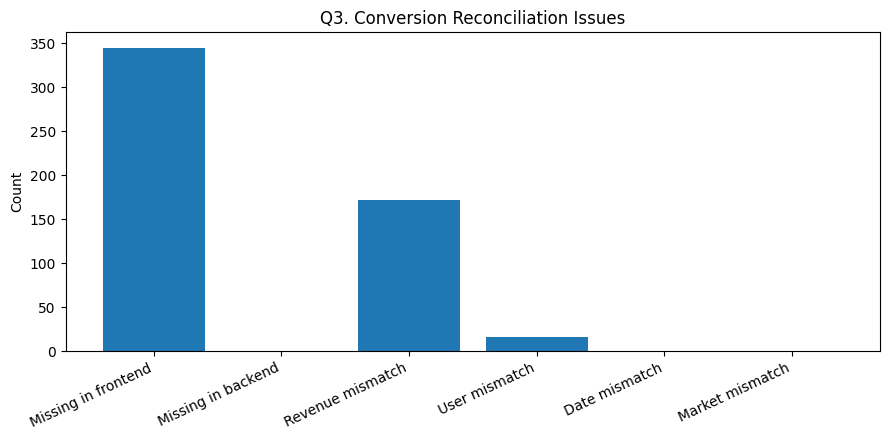

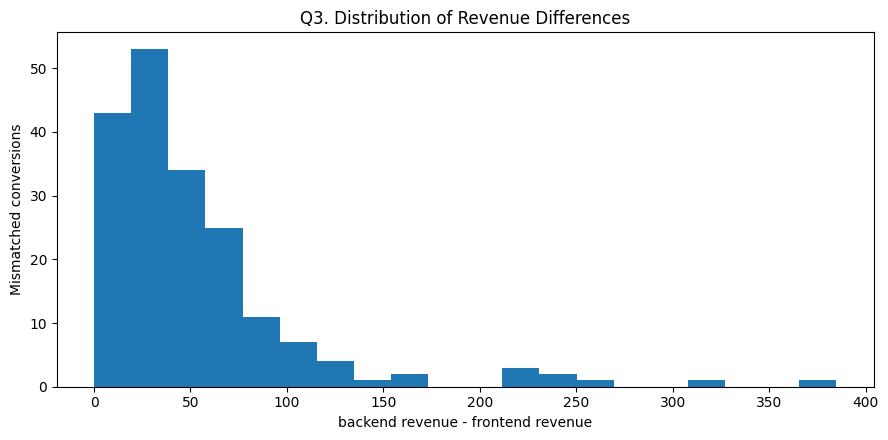

In [17]:
plt.figure(figsize=(9, 4.5))
plt.bar(issue_counts["Issue"], issue_counts["Count"])
plt.title("Q3. Conversion Reconciliation Issues")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

bad_conversions["revenue_diff"] = bad_conversions["b_revenue"] - bad_conversions["c_revenue"]
plt.figure(figsize=(9, 4.5))
plt.hist(bad_conversions["revenue_diff"], bins=20)
plt.title("Q3. Distribution of Revenue Differences")
plt.xlabel("backend revenue - frontend revenue")
plt.ylabel("Mismatched conversions")
plt.tight_layout()
plt.show()


**Simple conclusion for Q3**

- `conversions_backend` is the source of truth.
- There are **345** conversions missing from the frontend table.
- There are **172** revenue mismatches and **16** user mismatches.
- All revenue mismatches follow the same pattern: **frontend revenue = 0, backend revenue > 0**.


# Q4) Are attribution results consistent?

### What this question means
For each conversion, attribution says which sessions belong to the customer journey and how much credit each session gets through `ihc`.

A valid attribution result should satisfy at least these checks:
- the sum of `ihc` for one conversion should be close to **1**
- the sessions should belong to the **same user** as the conversion
- the conversion referenced in attribution should exist

### Important correction
For the cross-user check below, the notebook uses **`conversions_backend`** rather than `conversions`, because the backend table is the source of truth.


In [18]:
ihc_check = pd.read_sql_query(
    """
    SELECT
        conv_id,
        COUNT(*) AS n_sessions,
        SUM(ihc) AS ihc_sum,
        MIN(ihc) AS min_ihc,
        MAX(ihc) AS max_ihc
    FROM attribution_customer_journey
    GROUP BY conv_id
    ORDER BY conv_id
    """
, conn)

ihc_check.head()


,conv_id,n_sessions,ihc_sum,min_ihc,max_ihc
0,conv_id_1,1,1.0,1.00000,1.000000
1,conv_id_10,10,1.0,0.00000,0.333333
2,conv_id_100,2,1.0,0.50000,0.500000
3,conv_id_1000,2,1.0,0.00000,1.000000
4,conv_id_10002,2,1.0,0.44808,0.551920


In [19]:
bad_ihc = ihc_check[(ihc_check["ihc_sum"] - 1).abs() > 0.001].copy()

print("Conversions with materially bad ihc sum:", len(bad_ihc))
bad_ihc.sort_values(by="ihc_sum").head(20)


Conversions with materially bad ihc sum: 158


,conv_id,n_sessions,ihc_sum,min_ihc,max_ihc
428,conv_id_1091,1,0.000000,0.000000,0.000000
278,conv_id_10614,1,0.000000,0.000000,0.000000
2263,conv_id_15073,4,0.000000,0.000000,0.000000
4901,conv_id_5356,1,0.000000,0.000000,0.000000
5380,conv_id_642,1,0.000000,0.000000,0.000000
4296,conv_id_404,1,0.000000,0.000000,0.000000
2284,conv_id_15124,1,0.333342,0.333342,0.333342
6380,conv_id_8683,5,0.333517,0.000000,0.333517
6472,conv_id_8887,1,0.333610,0.333610,0.333610
6975,conv_id_9955,1,0.333617,0.333617,0.333617


In [20]:
cross_user_attr = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT a.conv_id) AS bad_conversions
    FROM attribution_customer_journey a
    JOIN conversions_backend b
        ON a.conv_id = b.conv_id
    JOIN session_sources s
        ON a.session_id = s.session_id
    WHERE b.user_id != s.user_id
    """
, conn)

cross_user_attr


,bad_rows,bad_conversions
0,7262,2584


In [21]:
attr_missing_conv = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS bad_rows,
        COUNT(DISTINCT a.conv_id) AS bad_conv_ids
    FROM attribution_customer_journey a
    LEFT JOIN conversions c
        ON a.conv_id = c.conv_id
    WHERE c.conv_id IS NULL
    """
, conn)

attr_missing_conv


,bad_rows,bad_conv_ids
0,392,138


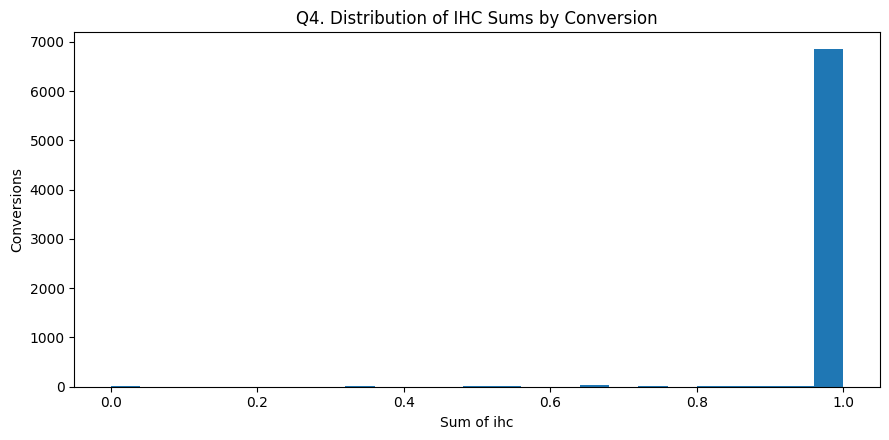

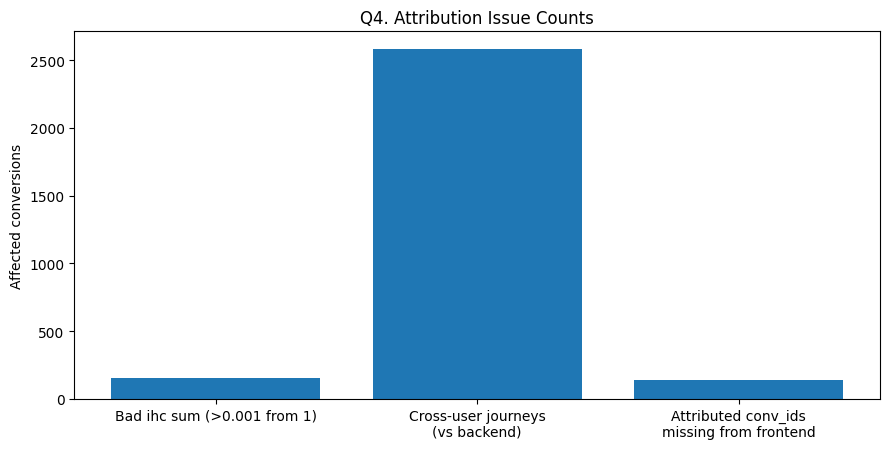

In [22]:
plt.figure(figsize=(9, 4.5))
plt.hist(ihc_check["ihc_sum"], bins=25)
plt.title("Q4. Distribution of IHC Sums by Conversion")
plt.xlabel("Sum of ihc")
plt.ylabel("Conversions")
plt.tight_layout()
plt.show()

q4_issue_counts = pd.DataFrame({
    "Issue": [
        "Bad ihc sum (>0.001 from 1)",
        "Cross-user journeys\n(vs backend)",
        "Attributed conv_ids\nmissing from frontend",
    ],
    "Count": [
        len(bad_ihc),
        int(cross_user_attr.loc[0, "bad_conversions"]),
        int(attr_missing_conv.loc[0, "bad_conv_ids"]),
    ]
})

plt.figure(figsize=(9, 4.6))
plt.bar(q4_issue_counts["Issue"], q4_issue_counts["Count"])
plt.title("Q4. Attribution Issue Counts")
plt.ylabel("Affected conversions")
plt.tight_layout()
plt.show()


**Simple conclusion for Q4**

- **158** conversions have materially wrong `ihc` sums.
- **2,584** conversions are linked to sessions from a different user when checked against the backend truth.
- **138** attributed conversion IDs are missing from the frontend conversion table.
- These are real attribution integrity issues, not just harmless decimal noise.


# Q5) Bonus — Do we have a channeling issue? Are sessions per channel stable over time?

### What this question means
We are checking whether:
- channel labels are clean and consistent
- channel counts behave normally over time

The clearest issue in this dataset is not a dramatic break in time series volume. It is **inconsistent naming**, which splits one business channel into multiple labels.


In [23]:
channel_counts = pd.read_sql_query(
    """
    SELECT
        channel_name,
        COUNT(*) AS sessions,
        MIN(event_date) AS first_date,
        MAX(event_date) AS last_date
    FROM session_sources
    GROUP BY channel_name
    ORDER BY sessions DESC
    """
, conn)

channel_counts


,channel_name,sessions,first_date,last_date
0,SEO,310277,2021-07-01,2021-07-31
1,Direct,211362,2021-07-01,2021-07-31
2,Shopping - Non-branded,205366,2021-07-01,2021-07-31
3,Social - Paid,177264,2021-07-01,2021-07-31
4,Email,110181,2021-07-01,2021-07-31
5,Direct Traffic,89945,2021-07-01,2021-07-31
6,SEA - Branded,79603,2021-07-01,2021-07-31
7,SEA - Brand,59943,2021-07-01,2021-07-31
8,Shopping - Non Brand,51133,2021-07-01,2021-07-31
9,SEA - Non-branded,46883,2021-07-01,2021-07-31


In [24]:
channel_daily = pd.read_sql_query(
    """
    SELECT
        event_date,
        channel_name,
        COUNT(*) AS sessions
    FROM session_sources
    GROUP BY event_date, channel_name
    ORDER BY event_date, channel_name
    """
, conn)

channel_daily.head(20)


,event_date,channel_name,sessions
0,2021-07-01,Affiliate,747
1,2021-07-01,Affiliates,311
2,2021-07-01,Direct,7437
3,2021-07-01,Direct Traffic,2896
4,2021-07-01,Display,732
5,2021-07-01,Email,1890
6,2021-07-01,Google Remarketing,94
7,2021-07-01,Influencers,892
8,2021-07-01,Referral,907
9,2021-07-01,SEA (no tagging),640


In [25]:
duplicate_label_check = channel_counts[channel_counts["channel_name"].isin([
    "Affiliate", "Affiliates",
    "Direct", "Direct Traffic",
    "SEA - Brand", "SEA - Branded",
    "SEA - Non-Brand", "SEA - Non-branded",
    "Shopping - Brand", "Shopping - Branded",
    "Shopping - Non Brand", "Shopping - Non-branded",
    "Social - Organic", "Social Organic",
    "Social - Paid", "Social Paid"
])]

duplicate_label_check


,channel_name,sessions,first_date,last_date
1,Direct,211362,2021-07-01,2021-07-31
2,Shopping - Non-branded,205366,2021-07-01,2021-07-31
3,Social - Paid,177264,2021-07-01,2021-07-31
5,Direct Traffic,89945,2021-07-01,2021-07-31
6,SEA - Branded,79603,2021-07-01,2021-07-31
7,SEA - Brand,59943,2021-07-01,2021-07-31
8,Shopping - Non Brand,51133,2021-07-01,2021-07-31
9,SEA - Non-branded,46883,2021-07-01,2021-07-31
11,SEA - Non-Brand,41030,2021-07-01,2021-07-31
12,Social Paid,33234,2021-07-01,2021-07-31


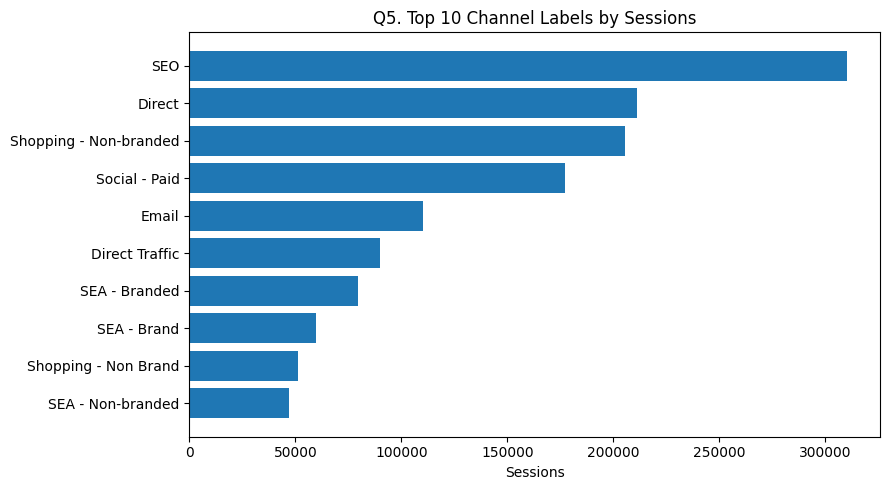

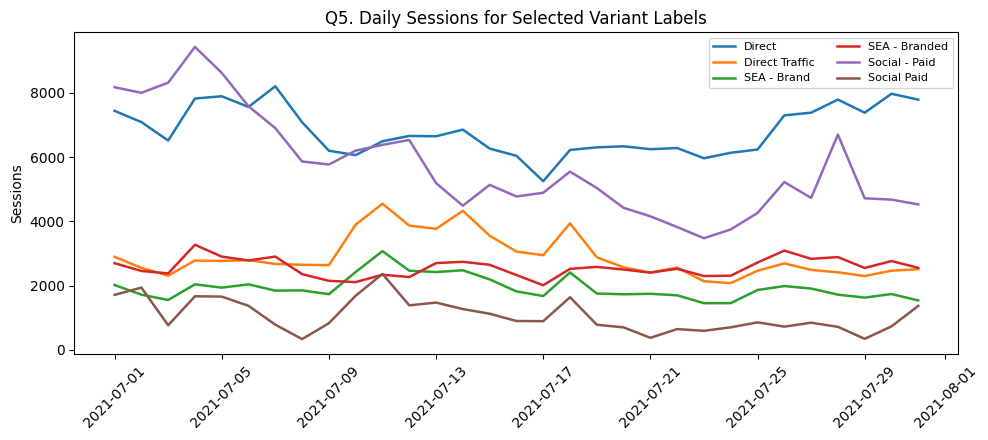

In [26]:
top_channels = channel_counts.head(10).sort_values("sessions")

plt.figure(figsize=(9, 5))
plt.barh(top_channels["channel_name"], top_channels["sessions"])
plt.title("Q5. Top 10 Channel Labels by Sessions")
plt.xlabel("Sessions")
plt.tight_layout()
plt.show()

variant_names = ["Direct", "Direct Traffic", "SEA - Brand", "SEA - Branded", "Social - Paid", "Social Paid"]
variants = channel_daily[channel_daily["channel_name"].isin(variant_names)].copy()
variants["event_date"] = pd.to_datetime(variants["event_date"])
pivot = variants.pivot(index="event_date", columns="channel_name", values="sessions").fillna(0)

plt.figure(figsize=(10, 4.5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], linewidth=1.8, label=col)
plt.title("Q5. Daily Sessions for Selected Variant Labels")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


**Simple conclusion for Q5**

- The biggest channel issue is **inconsistent naming**.
- Examples include `Direct` vs `Direct Traffic`, `SEA - Brand` vs `SEA - Branded`, and `Social - Paid` vs `Social Paid`.
- Because of this, channel reporting is **not fully reliable** unless labels are standardized first.


# Q6) Bonus — Any other issues?

Below are a few small but useful extra checks.


In [27]:
api_zero_click_cost = pd.read_sql_query(
    """
    SELECT *
    FROM api_adwords_costs
    WHERE clicks = 0
      AND cost > 0
    ORDER BY cost DESC
    """
, conn)

api_zero_click_cost.head(10)


,event_date,campaign_id,cost,clicks
0,2021-07-02,campaign_id_156,7.031,0
1,2021-07-17,campaign_id_94,6.975,0
2,2021-07-11,campaign_id_94,5.976,0
3,2021-07-04,campaign_id_94,3.908,0
4,2021-07-05,campaign_id_156,3.816,0
5,2021-07-10,campaign_id_94,3.458,0
6,2021-07-01,campaign_id_7,1.844,0
7,2021-07-20,campaign_id_94,1.368,0
8,2021-07-09,campaign_id_7,1.108,0
9,2021-07-20,campaign_id_7,1.067,0


In [28]:
conv_zero = pd.read_sql_query("SELECT COUNT(*) AS n FROM conversions WHERE revenue = 0", conn)["n"].iloc[0]
backend_zero = pd.read_sql_query("SELECT COUNT(*) AS n FROM conversions_backend WHERE revenue = 0", conn)["n"].iloc[0]

print(f"conversions: {conv_zero} zero-revenue rows")
print(f"conversions_backend: {backend_zero} zero-revenue rows")


conversions: 197 zero-revenue rows
conversions_backend: 27 zero-revenue rows


In [29]:
other_issues = pd.DataFrame({
    "Issue": [
        "API rows with cost > 0 but clicks = 0",
        "Zero-revenue rows in conversions",
        "Zero-revenue rows in conversions_backend",
    ],
    "Count": [
        len(api_zero_click_cost),
        int(conv_zero),
        int(backend_zero),
    ]
})

other_issues


,Issue,Count
0,API rows with cost > 0 but clicks = 0,10
1,Zero-revenue rows in conversions,197
2,Zero-revenue rows in conversions_backend,27


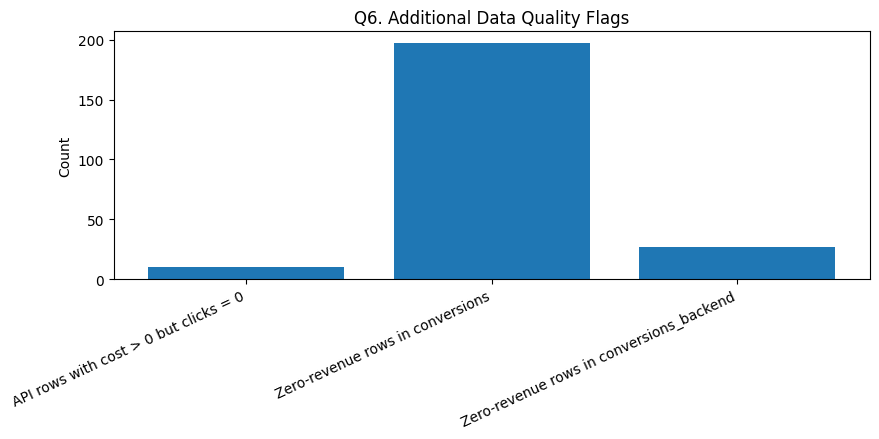

In [30]:
plt.figure(figsize=(9, 4.5))
plt.bar(other_issues["Issue"], other_issues["Count"])
plt.title("Q6. Additional Data Quality Flags")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Final summary

### Main findings
1. **Adwords cost coverage is high but incomplete.** The main problem campaign is `campaign_id_79`, and two campaigns are missing from session data.
2. **Conversions are fairly stable over the available period**, but the frontend table is below the backend table every day.
3. **Frontend conversions do not fully reconcile to backend truth.** Missing rows and zero-revenue rows are the main defects.
4. **Attribution contains real integrity issues**, especially cross-user journeys and non-unit `ihc` sums.
5. **Channel naming is inconsistent**, which weakens channel-level reporting.

### Most important practical takeaway
If this were a real production system, the first fixes to prioritize would be:
- frontend conversion reconciliation against backend
- attribution logic and customer-journey linkage
- campaign and channel labeling standardization


# Bonus section — Machine Learning and Advanced Analytics Extensions

The core challenge is still best solved with **deterministic data-quality checks** (joins, aggregations, and rule-based validation).  
This section keeps the earlier analysis unchanged and adds **supplementary ML-style methods** that can help surface anomalies, prioritize investigation, and suggest root-cause patterns.

These additions are optional and should be interpreted as **exploratory support**, not as replacements for the SQL reconciliation checks.


In [ ]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')


## ML 1) Daily anomaly detection across cost, sessions, and conversions

### Why this is useful
Instead of visually inspecting each daily chart, we can build one daily feature table and let an anomaly detector flag the most unusual days automatically.

### What the model uses
For each day in July 2021, we combine:
- API cost and clicks
- session CPC and session counts
- total sessions
- backend/frontend conversion counts and revenue
- gap variables and simple channel-mix entropy

### Model
We use **Isolation Forest**, an unsupervised anomaly detection model.


In [ ]:
# Rebuild the daily feature table in one place for ML-style analysis
q1_daily_ml = q1.groupby('event_date', as_index=False)[['api_cost', 'session_cost', 'api_clicks', 'session_rows', 'cost_gap', 'click_gap']].sum().copy()
q1_daily_ml['event_date'] = pd.to_datetime(q1_daily_ml['event_date'])
q1_daily_ml['cost_coverage'] = q1_daily_ml['session_cost'] / q1_daily_ml['api_cost']
q1_daily_ml['click_coverage'] = q1_daily_ml['session_rows'] / q1_daily_ml['api_clicks']

conv_compare_daily_ml = conv_compare_daily.copy()
conv_compare_daily_ml['conv_date'] = pd.to_datetime(conv_compare_daily_ml['conv_date'])
conv_compare_daily_ml['front_backend_ratio'] = conv_compare_daily_ml['front_cnt'] / conv_compare_daily_ml['backend_cnt']
conv_compare_daily_ml['rev_ratio'] = conv_compare_daily_ml['front_rev'] / conv_compare_daily_ml['backend_rev']

sess_daily_ml = channel_daily.copy()
sess_daily_ml['event_date'] = pd.to_datetime(sess_daily_ml['event_date'])
channel_pivot_ml = sess_daily_ml.pivot(index='event_date', columns='channel_name', values='sessions').fillna(0)
channel_share_ml = channel_pivot_ml.div(channel_pivot_ml.sum(axis=1), axis=0)
channel_entropy = -(channel_share_ml.replace(0, np.nan) * np.log(channel_share_ml.replace(0, np.nan))).sum(axis=1).fillna(0)

all_dates = pd.DataFrame({'date': pd.date_range('2021-07-01', '2021-07-31')})
daily_ml = all_dates.merge(q1_daily_ml.rename(columns={'event_date': 'date'}), on='date', how='left')
daily_ml = daily_ml.merge(channel_pivot_ml.sum(axis=1).rename('total_sessions'), left_on='date', right_index=True, how='left')
daily_ml = daily_ml.merge(channel_entropy.rename('channel_entropy'), left_on='date', right_index=True, how='left')
daily_ml = daily_ml.merge(conv_compare_daily_ml.rename(columns={'conv_date': 'date'}), on='date', how='left')
daily_ml = daily_ml.fillna(0)

feature_cols = [c for c in daily_ml.columns if c != 'date']
X_daily = StandardScaler().fit_transform(daily_ml[feature_cols])

daily_iforest = IsolationForest(random_state=42, contamination=0.15)
daily_ml['iforest_flag'] = (daily_iforest.fit_predict(X_daily) == -1).astype(int)
daily_ml['iforest_anomaly_score'] = -daily_iforest.score_samples(X_daily)

daily_anomalies = daily_ml[['date', 'iforest_anomaly_score', 'iforest_flag']].sort_values('iforest_anomaly_score', ascending=False)
daily_anomalies.head(10)


In [ ]:
plt.figure(figsize=(10, 4.5))
plt.plot(daily_ml['date'], daily_ml['iforest_anomaly_score'], marker='o')
flagged = daily_ml[daily_ml['iforest_flag'] == 1]
plt.scatter(flagged['date'], flagged['iforest_anomaly_score'], s=70, label='Flagged anomaly')
for _, row in flagged.iterrows():
    plt.annotate(row['date'].strftime('%Y-%m-%d'), (row['date'], row['iforest_anomaly_score']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.title('ML 1. Isolation Forest anomaly score by day')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print('Top flagged days:')
print(flagged[['date', 'iforest_anomaly_score']].sort_values('iforest_anomaly_score', ascending=False).to_string(index=False))


**Interpretation**  
This method is useful for prioritization. In this dataset, it should flag days that are unusual because of a combination of: large cost/session mismatches, unusual conversion gaps, or unusual channel/session mix. It does not prove the root cause by itself; it points you to the days that deserve manual review first.


## ML 2) Simple change-point detection on frontend vs backend gaps

### Why this is useful
The task asks whether conversions are stable over time. A simple change-point scan tries to find the date where the average gap changes most strongly.

### Method
For the daily conversion-count gap and daily revenue gap, we test every possible split and choose the one that gives the best two-segment fit.

This is not a heavy model, but it is a very practical time-series diagnostic.


In [ ]:
def best_single_change_point(series, min_seg=3):
    values = np.asarray(series, dtype=float)
    best = None
    for i in range(min_seg, len(values) - min_seg + 1):
        left = values[:i]
        right = values[i:]
        sse = ((left - left.mean()) ** 2).sum() + ((right - right.mean()) ** 2).sum()
        if best is None or sse < best['sse']:
            best = {
                'split_idx': i,
                'sse': sse,
                'left_mean': left.mean(),
                'right_mean': right.mean(),
            }
    return best

cnt_gap_cp = best_single_change_point(conv_compare_daily_ml['cnt_gap'])
rev_gap_cp = best_single_change_point(conv_compare_daily_ml['rev_gap'])

cnt_gap_date = conv_compare_daily_ml.iloc[cnt_gap_cp['split_idx']]['conv_date']
rev_gap_date = conv_compare_daily_ml.iloc[rev_gap_cp['split_idx']]['conv_date']

print('Best single change-point for count gap:')
print(cnt_gap_cp, 'date =', cnt_gap_date.date())
print('\nBest single change-point for revenue gap:')
print(rev_gap_cp, 'date =', rev_gap_date.date())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(conv_compare_daily_ml['conv_date'], conv_compare_daily_ml['cnt_gap'], marker='o')
axes[0].axvline(cnt_gap_date, linestyle='--', label=f'Best split: {cnt_gap_date.date()}')
axes[0].set_title('ML 2A. Daily conversion count gap')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].plot(conv_compare_daily_ml['conv_date'], conv_compare_daily_ml['rev_gap'], marker='o')
axes[1].axvline(rev_gap_date, linestyle='--', label=f'Best split: {rev_gap_date.date()}')
axes[1].set_title('ML 2B. Daily revenue gap')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretation**  
Because the conversion window is short, this is only a weak signal. Still, it helps answer the stability question more formally by showing whether the frontend-vs-backend gap looks roughly constant or whether it shifts toward the end of the month.


## ML 3) Campaign-level anomaly detection and clustering

### Why this is useful
Question 1 is about coverage of API costs in session data. A model can help surface the campaigns with the strangest mismatch profiles automatically.

### Methods
1. **Isolation Forest** to rank campaigns by anomaly score  
2. **K-Means clustering** to group campaigns into issue profiles


In [ ]:
campaign_ml = campaign_issues.copy()
campaign_ml['cost_coverage'] = campaign_ml['session_cost'] / campaign_ml['api_cost']
campaign_ml['click_coverage'] = campaign_ml['session_rows'] / campaign_ml['api_clicks']

campaign_feature_cols = ['api_cost', 'api_clicks', 'session_rows', 'session_cost', 'cost_gap', 'click_gap', 'cost_coverage', 'click_coverage']
X_campaign = campaign_ml[campaign_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_campaign_scaled = StandardScaler().fit_transform(X_campaign)

campaign_iforest = IsolationForest(random_state=42, contamination=0.10)
campaign_ml['iforest_flag'] = (campaign_iforest.fit_predict(X_campaign_scaled) == -1).astype(int)
campaign_ml['iforest_anomaly_score'] = -campaign_iforest.score_samples(X_campaign_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
campaign_ml['cluster'] = kmeans.fit_predict(X_campaign_scaled)

campaign_ml.sort_values('iforest_anomaly_score', ascending=False).head(12)[['campaign_id', 'api_cost', 'session_cost', 'cost_gap', 'click_gap', 'cost_coverage', 'click_coverage', 'cluster', 'iforest_anomaly_score']]


In [ ]:
plt.figure(figsize=(10, 5))
colors = campaign_ml['cluster']
plt.scatter(campaign_ml['api_cost'], campaign_ml['cost_gap'], c=colors, s=35)
flagged_campaigns = campaign_ml[campaign_ml['iforest_flag'] == 1]
plt.scatter(flagged_campaigns['api_cost'], flagged_campaigns['cost_gap'], s=120, facecolors='none', edgecolors='black', linewidths=1.2, label='Isolation Forest flag')
for _, row in flagged_campaigns.sort_values('iforest_anomaly_score', ascending=False).head(8).iterrows():
    plt.annotate(row['campaign_id'], (row['api_cost'], row['cost_gap']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.xscale('log')
plt.title('ML 3. Campaign issue map: API cost vs cost gap')
plt.xlabel('API cost (log scale)')
plt.ylabel('Cost gap (API - session CPC)')
plt.legend()
plt.tight_layout()
plt.show()

cluster_summary = campaign_ml.groupby('cluster')[campaign_feature_cols].mean().round(3)
print('Cluster summary:')
print(cluster_summary)
print('\nMost anomalous campaigns:')
print(campaign_ml.sort_values('iforest_anomaly_score', ascending=False).head(10)[['campaign_id', 'cost_gap', 'click_gap', 'cost_coverage', 'iforest_anomaly_score']].to_string(index=False))

**Interpretation**  
This extension should surface the same campaigns already found by rule-based checks, but in a way that scales: highly unusual campaigns, campaigns with zero coverage, and campaigns with strong click mismatches cluster into distinct issue profiles.


## ML 4) Daily channel-mix anomaly detection with PCA

### Why this is useful
For the channeling question, we already found naming inconsistencies. A complementary ML-style check asks whether any **day-level channel mix** is unusual even if total sessions stay normal.

### Methods
- **PCA** to compress the daily channel mix into two dimensions for visualization
- **Isolation Forest** on the channel-share matrix to flag unusual days


In [ ]:
channel_share_nonzero = channel_share_ml.loc[channel_share_ml.sum(axis=1) > 0].copy()
X_channel_mix = StandardScaler().fit_transform(channel_share_nonzero)

channel_mix_iforest = IsolationForest(random_state=42, contamination=0.15)
channel_mix_flags = (channel_mix_iforest.fit_predict(X_channel_mix) == -1).astype(int)
channel_mix_scores = -channel_mix_iforest.score_samples(X_channel_mix)

pca = PCA(n_components=2, random_state=42)
channel_mix_pca = pca.fit_transform(X_channel_mix)

channel_mix_plot = pd.DataFrame({
    'date': channel_share_nonzero.index,
    'pc1': channel_mix_pca[:, 0],
    'pc2': channel_mix_pca[:, 1],
    'iforest_flag': channel_mix_flags,
    'anomaly_score': channel_mix_scores,
})

print('Explained variance by the first two PCs:', pca.explained_variance_ratio_)
channel_mix_plot.sort_values('anomaly_score', ascending=False).head(10)


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(channel_mix_plot['pc1'], channel_mix_plot['pc2'], c=channel_mix_plot['iforest_flag'], s=60)
for _, row in channel_mix_plot[channel_mix_plot['iforest_flag'] == 1].iterrows():
    plt.annotate(row['date'].strftime('%Y-%m-%d'), (row['pc1'], row['pc2']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.title('ML 4. PCA map of daily channel mix')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print('Most unusual channel-mix days:')
print(channel_mix_plot.sort_values('anomaly_score', ascending=False).head(10)[['date', 'anomaly_score', 'iforest_flag']].to_string(index=False))


**Interpretation**  
If this section highlights days that also look unusual in the base session charts, that strengthens the case that the mix changed. If not, it suggests the main channel problem is still naming inconsistency rather than volume instability.


## ML 5) Text-based similarity analysis for channel-name normalization

### Why this is useful
The base analysis found several duplicate or near-duplicate channel labels. We can automate that discovery using a lightweight NLP approach.

### Method
We vectorize each unique channel name using **character n-gram TF-IDF** and compute **cosine similarity** between labels.


In [ ]:
channel_labels = pd.read_sql_query('SELECT DISTINCT channel_name FROM session_sources ORDER BY channel_name', conn)['channel_name'].tolist()
channel_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4))
channel_matrix = channel_vectorizer.fit_transform(channel_labels)
channel_similarity = cosine_similarity(channel_matrix)

similar_label_pairs = []
for i, a in enumerate(channel_labels):
    for j in range(i + 1, len(channel_labels)):
        score = channel_similarity[i, j]
        if score >= 0.60 and a != channel_labels[j]:
            similar_label_pairs.append((a, channel_labels[j], score))

similar_label_pairs_df = pd.DataFrame(similar_label_pairs, columns=['label_1', 'label_2', 'cosine_similarity'])
similar_label_pairs_df = similar_label_pairs_df.sort_values('cosine_similarity', ascending=False)
similar_label_pairs_df.head(15)


In [ ]:
top_pairs = similar_label_pairs_df.head(12).copy()
plot_labels = top_pairs['label_1'] + '  ~  ' + top_pairs['label_2']
plt.figure(figsize=(10, 5))
plt.barh(plot_labels[::-1], top_pairs['cosine_similarity'][::-1])
plt.title('ML 5. Most similar channel-label pairs by TF-IDF cosine similarity')
plt.xlabel('Cosine similarity')
plt.tight_layout()
plt.show()

print(top_pairs.to_string(index=False))


**Interpretation**  
This is useful for automatic standardization suggestions. It does not replace business judgment, because some highly similar strings may still be semantically different. But it is very effective for surfacing obvious duplicates such as `Social - Organic` vs `Social Organic`.


## ML 6) Attribution-journey anomaly scoring

### Why this is useful
Question 4 asks whether attribution results are consistent. The rule-based checks are still primary, but we can score whole conversion journeys to identify the most suspicious ones first.

### Features per conversion journey
Using `conversions_backend` as the true conversion table, we create one row per conversion with features such as:
- number of touchpoints
- `ihc` sum and absolute error from 1
- channel diversity
- time span of the journey
- cross-user flag
- missing-session flag
- future-session flag
- revenue

### Model
We again use **Isolation Forest**.


In [ ]:
journey_ml = pd.read_sql_query(
    '''
    WITH journey_base AS (
        SELECT
            b.conv_id,
            b.user_id AS conv_user_id,
            b.conv_date,
            b.market,
            b.revenue,
            COUNT(a.session_id) AS n_touchpoints,
            SUM(COALESCE(a.ihc, 0)) AS ihc_sum,
            MIN(a.ihc) AS min_ihc,
            MAX(a.ihc) AS max_ihc,
            COUNT(DISTINCT s.channel_name) AS distinct_channels,
            COUNT(DISTINCT s.event_date) AS distinct_session_dates,
            MIN(s.event_date) AS first_session_date,
            MAX(s.event_date) AS last_session_date,
            MAX(CASE WHEN s.session_id IS NULL AND a.session_id IS NOT NULL THEN 1 ELSE 0 END) AS missing_session_flag,
            MAX(CASE WHEN s.user_id IS NOT NULL AND s.user_id != b.user_id THEN 1 ELSE 0 END) AS cross_user_flag,
            MAX(CASE WHEN s.event_date IS NOT NULL AND s.event_date > b.conv_date THEN 1 ELSE 0 END) AS future_session_flag
        FROM conversions_backend b
        LEFT JOIN attribution_customer_journey a
            ON b.conv_id = a.conv_id
        LEFT JOIN session_sources s
            ON a.session_id = s.session_id
        GROUP BY b.conv_id, b.user_id, b.conv_date, b.market, b.revenue
    )
    SELECT
        *,
        ABS(COALESCE(ihc_sum, 0) - 1.0) AS ihc_abs_error,
        CASE WHEN n_touchpoints = 0 THEN 1 ELSE 0 END AS missing_attribution_flag,
        CASE WHEN first_session_date IS NOT NULL THEN julianday(conv_date) - julianday(first_session_date) END AS days_from_first_touch_to_conversion,
        CASE WHEN first_session_date IS NOT NULL AND last_session_date IS NOT NULL THEN julianday(last_session_date) - julianday(first_session_date) END AS journey_span_days
    FROM journey_base
    ''',
    conn,
)

journey_feature_cols = [
    'n_touchpoints', 'ihc_sum', 'min_ihc', 'max_ihc', 'distinct_channels', 'distinct_session_dates',
    'missing_session_flag', 'cross_user_flag', 'future_session_flag', 'ihc_abs_error',
    'missing_attribution_flag', 'days_from_first_touch_to_conversion', 'journey_span_days', 'revenue'
]

X_journey = journey_ml[journey_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_journey_scaled = StandardScaler().fit_transform(X_journey)

journey_iforest = IsolationForest(random_state=42, contamination=0.02, n_estimators=200)
journey_ml['iforest_flag'] = (journey_iforest.fit_predict(X_journey_scaled) == -1).astype(int)
journey_ml['iforest_anomaly_score'] = -journey_iforest.score_samples(X_journey_scaled)

journey_ml.sort_values('iforest_anomaly_score', ascending=False).head(12)[['conv_id', 'n_touchpoints', 'ihc_sum', 'ihc_abs_error', 'cross_user_flag', 'missing_session_flag', 'future_session_flag', 'iforest_anomaly_score']]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(journey_ml['iforest_anomaly_score'], bins=30)
axes[0].set_title('ML 6A. Distribution of journey anomaly scores')

flagged_journeys = journey_ml[journey_ml['iforest_flag'] == 1]
axes[1].scatter(journey_ml['n_touchpoints'], journey_ml['ihc_abs_error'], s=10, alpha=0.5)
axes[1].scatter(flagged_journeys['n_touchpoints'], flagged_journeys['ihc_abs_error'], s=30, alpha=0.9, label='Flagged')
axes[1].set_title('ML 6B. Touchpoints vs absolute IHC error')
axes[1].set_xlabel('Number of touchpoints')
axes[1].set_ylabel('|IHC sum - 1|')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Flagged journey count:', int(journey_ml['iforest_flag'].sum()))
print('Share of flagged journeys with cross-user issue:', round(flagged_journeys['cross_user_flag'].mean(), 3))
print('Share of flagged journeys with materially bad IHC sum:', round((flagged_journeys['ihc_abs_error'] > 0.001).mean(), 3))
print('\nTop anomalous journeys:')
print(journey_ml.sort_values('iforest_anomaly_score', ascending=False).head(10)[['conv_id', 'n_touchpoints', 'ihc_sum', 'cross_user_flag', 'missing_session_flag', 'future_session_flag', 'iforest_anomaly_score']].to_string(index=False))

**Interpretation**  
This is a triage tool: it helps identify the conversions whose journeys look globally unusual, not just those that fail one single rule. In this dataset, highly anomalous journeys are expected to concentrate among cross-user and bad-`ihc` cases.


## ML 7) Supervised model to explain which backend conversions go missing in frontend tracking

### Why this is useful
Question 3 shows that some backend conversions are absent from the frontend conversion table. A supervised model can help answer a different question:

> Given the features we do have, can we predict which backend conversions are likely to be missing in frontend tracking?

### Target
- `1` = conversion exists in backend but not in frontend
- `0` = conversion exists in both

### Models
- **Logistic Regression** for a simple, interpretable baseline
- **Random Forest** for non-linear interactions

This is still exploratory: weak model performance would mean the missingness pattern is not well explained by the available features.


In [ ]:
frontend_presence = pd.read_sql_query('SELECT conv_id, 1 AS in_frontend FROM conversions', conn)
model_df = journey_ml.merge(frontend_presence, on='conv_id', how='left')
model_df['in_frontend'] = model_df['in_frontend'].fillna(0).astype(int)
model_df['missing_frontend'] = 1 - model_df['in_frontend']
model_df['weekday'] = pd.to_datetime(model_df['conv_date']).dt.weekday
model_df['day_of_month'] = pd.to_datetime(model_df['conv_date']).dt.day

num_features = [
    'revenue', 'n_touchpoints', 'ihc_sum', 'min_ihc', 'max_ihc', 'distinct_channels', 'distinct_session_dates',
    'missing_session_flag', 'cross_user_flag', 'future_session_flag', 'ihc_abs_error', 'missing_attribution_flag',
    'days_from_first_touch_to_conversion', 'journey_span_days', 'weekday', 'day_of_month'
]
cat_features = ['market']

y = model_df['missing_frontend']
X = model_df[num_features + cat_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

logit_pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
])
logit_model = Pipeline([
    ('pre', logit_pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
logit_model.fit(X_train, y_train)
logit_scores = logit_model.predict_proba(X_test)[:, 1]

rf_pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_features),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
])
rf_model = Pipeline([
    ('pre', rf_pre),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample',
        min_samples_leaf=5,
        n_jobs=-1,
    )),
])
rf_model.fit(X_train, y_train)
rf_scores = rf_model.predict_proba(X_test)[:, 1]

model_metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC AUC': [roc_auc_score(y_test, logit_scores), roc_auc_score(y_test, rf_scores)],
    'Average Precision': [average_precision_score(y_test, logit_scores), average_precision_score(y_test, rf_scores)],
})
model_metrics


In [ ]:
rf_importance = pd.DataFrame({
    'feature': rf_model.named_steps['pre'].get_feature_names_out(),
    'importance': rf_model.named_steps['clf'].feature_importances_,
}).sort_values('importance', ascending=False)

top_rf_importance = rf_importance.head(12).copy()
plt.figure(figsize=(10, 5))
plt.barh(top_rf_importance['feature'][::-1], top_rf_importance['importance'][::-1])
plt.title('ML 7. Random Forest feature importance for missing frontend conversions')
plt.tight_layout()
plt.show()

print(model_metrics.to_string(index=False))
print('\nTop Random Forest features:')
print(top_rf_importance.to_string(index=False))

**Interpretation**  
If the model scores are only slightly above random, that is an honest result: it means the missing-frontend problem is not easily explained by the limited fields available here. That is still useful, because it suggests the root cause may live in missing technical metadata rather than obvious business attributes.


## ML-style extension summary

These additional methods do **not replace** the core findings. They extend them in these ways:

1. **Daily anomaly detection** prioritizes unusual dates for manual review.  
2. **Change-point detection** formalizes the stability question for frontend vs backend gaps.  
3. **Campaign anomaly detection and clustering** helps surface problematic campaigns at scale.  
4. **PCA on channel mix** checks whether day-level channel composition is unusual.  
5. **NLP similarity on channel names** automates duplicate-label discovery.  
6. **Journey anomaly scoring** prioritizes suspicious attribution paths.  
7. **Supervised learning** explores whether missing frontend conversions follow predictable patterns.

For this challenge, the SQL-based reconciliation remains the main answer. The ML section is best presented as a **bonus analytical layer**.
